<a href="https://colab.research.google.com/github/nwon24/nlp/blob/main/W8/BERT_with_interactive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine tuning a BERT model for text classification

BERT (Bidirectional encoder representations from transformers) is a special kind of transfomer architecture that has wide applications in NLP.

# Imports

In [1]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader,Dataset
from torch.optim import Adam
from torch.nn import BCEWithLogitsLoss,BCELoss
from torch import accelerator
from torch import tensor
from torch.nn import Sigmoid
from transformers import BertForSequenceClassification
from transformers import AutoTokenizer


Here it's handy as well to set a variable that will hold the device we want to train the model on. That way we don't have to manually change the device if we no longer have  GPU.

In [2]:
device=accelerator.current_accelerator().type if accelerator.is_available() else "cpu"

# Hyperparameters

In [3]:
batch_size=32
lr=1e-5
epochs=1

# Data preparation and tokenisation

Our corpus is a CSV file of Amazon reviews eith three columns: label, title of the review, and the text of the review itself.

For the tokeniser, we are lucky to have a pretrained tokeniser from `AutoTokenizer`. This tokenizer returns the tokens of the corpus in a special dictionary, which will be used in the `DataLoader` class to feed the input correctly into the model. The output of the tokenizer is a dictionary with keys `input_ids`, `token_type_ids`, and `attention_mask`, so we can't just use our homeegrown tokenizer or that of `CounntVectorizer` anymore. We can, however, still use the `LabelEncoder` from `sklearn` to convert our labels into ones and zeroes.




In [4]:
corpus_file="xaa"
data=pd.read_csv(corpus_file,encoding="utf-8")
trainX,testX,trainY,testY=train_test_split(data["text"],data["label"],test_size=0.2)

label_encoder=LabelEncoder()

tokenizer=AutoTokenizer.from_pretrained("google-bert/bert-base-cased")
train_tokens=tokenizer(list(trainX),truncation=True,padding=True)
test_tokens=tokenizer(list(testX),truncation=True,padding=True)
train_labels=label_encoder.fit_transform(trainY)
test_labels=label_encoder.transform(testY)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


# Loading the data

Models implemented in `torch` can be trained by feeding input data through the `DataLoader` and `DataSet` classes. This ensures that the data comes in the specified batches and that the data is also shuffled around.

To implement our own class that inherits from `DataLoader`, we just need to define a copy of basic methods: a method to return the amount of data we have, and a method to return the both the input and and the corresponding output given an index. In this case we have included the labels in the dictionary that is returned, but we could also have returned the labels separately.

In [5]:
class token_data(Dataset):
    def __init__(self,data,tokens,labels):
        # self.data will hold raw data (not tokenized) for __len__ method
        self.data=data
        self.tokens=tokens
        self.labels=labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self,idx):
        item={}
        for k,v in self.tokens.items():
            item[k]=tensor(v[idx])
        item["labels"]=tensor(self.labels[idx]).float()
        return item

Now that we have our  own `token_data` class, all that is required is to wrap our data using the `DataLoader` class.

In [6]:
train_loader=DataLoader(token_data(trainX,train_tokens,train_labels),shuffle=True,batch_size=batch_size)
test_loader=DataLoader(token_data(testX,test_tokens,test_labels),shuffle=False,batch_size=batch_size)

# Loading the pretrained BERT model

We use binary cross entropy loss because our classification task is binary---the reviews are either positive or negative.

In [7]:
model=BertForSequenceClassification.from_pretrained("google-bert/bert-base-cased",num_labels=1).to(device)
optimizer=Adam(model.parameters(),lr=lr)
loss_fn=BCEWithLogitsLoss()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Training


In [8]:
model.train()

for epoch in range(epochs):
    batch_loss=0
    for i,batch in enumerate(train_loader):
        optimizer.zero_grad()
        input_ids=batch["input_ids"].to(device)
        attention_mask=batch["attention_mask"].to(device)
        labels=batch["labels"].to(device)

        prediction=model(input_ids,attention_mask=attention_mask)
        loss=loss_fn(prediction.logits.flatten(),labels)
        loss.backward()
        optimizer.step()

        batch_loss+=loss.item()
        current_loss=loss.item()
        print(f"Batch {i}, loss {current_loss:.6f}")
    print(f"Epoch {epoch}, loss {batch_loss/batch_size:.6f}")

Batch 0, loss 0.761432
Batch 1, loss 0.676439
Batch 2, loss 0.726415
Batch 3, loss 0.672366
Batch 4, loss 0.722993
Batch 5, loss 0.665844
Batch 6, loss 0.654715
Batch 7, loss 0.650773
Batch 8, loss 0.677535
Batch 9, loss 0.639554
Batch 10, loss 0.682302
Batch 11, loss 0.675658
Batch 12, loss 0.604863
Batch 13, loss 0.632823
Batch 14, loss 0.636185
Batch 15, loss 0.624512
Batch 16, loss 0.647985
Batch 17, loss 0.713662
Batch 18, loss 0.622089
Batch 19, loss 0.615374
Batch 20, loss 0.643415
Batch 21, loss 0.571498
Batch 22, loss 0.648440
Batch 23, loss 0.581268
Batch 24, loss 0.599295
Batch 25, loss 0.595591
Batch 26, loss 0.661834
Batch 27, loss 0.554015
Batch 28, loss 0.552628
Batch 29, loss 0.565503
Batch 30, loss 0.605907
Batch 31, loss 0.538962
Batch 32, loss 0.598735
Batch 33, loss 0.585185
Batch 34, loss 0.533829
Batch 35, loss 0.471638
Batch 36, loss 0.490844
Batch 37, loss 0.464116
Batch 38, loss 0.520889
Batch 39, loss 0.490913
Batch 40, loss 0.436355
Batch 41, loss 0.480441
Ba

# Testing

To turn the predictions back into labels, we need to apply the `Sigmoid()` activation function on the `logits` of the prediction. This is because the `logit` function is the inverse of the `Sigmoid` function.

Batch 0, loss 0.007618
Accuracy: 0.87500
Batch 1, loss 0.004643
Accuracy: 0.89062
Batch 2, loss 0.006804
Accuracy: 0.89583
Batch 3, loss 0.010123
Accuracy: 0.87500
Batch 4, loss 0.010024
Accuracy: 0.86875
Batch 5, loss 0.009747
Accuracy: 0.85938
Batch 6, loss 0.009572
Accuracy: 0.86161
Batch 7, loss 0.009943
Accuracy: 0.86328
Batch 8, loss 0.010131
Accuracy: 0.86806
Batch 9, loss 0.009266
Accuracy: 0.86562
Batch 10, loss 0.004307
Accuracy: 0.87216
Batch 11, loss 0.007497
Accuracy: 0.87240
Batch 12, loss 0.005777
Accuracy: 0.87740
Batch 13, loss 0.005736
Accuracy: 0.88170
Batch 14, loss 0.002616
Accuracy: 0.88958
Batch 15, loss 0.005993
Accuracy: 0.89062
Batch 16, loss 0.005416
Accuracy: 0.89154
Batch 17, loss 0.004586
Accuracy: 0.89583
Batch 18, loss 0.007683
Accuracy: 0.89638
Batch 19, loss 0.007849
Accuracy: 0.89687
Batch 20, loss 0.003134
Accuracy: 0.90179
Batch 21, loss 0.010013
Accuracy: 0.89915
Batch 22, loss 0.011320
Accuracy: 0.89538
Batch 23, loss 0.009622
Accuracy: 0.89323
Ba

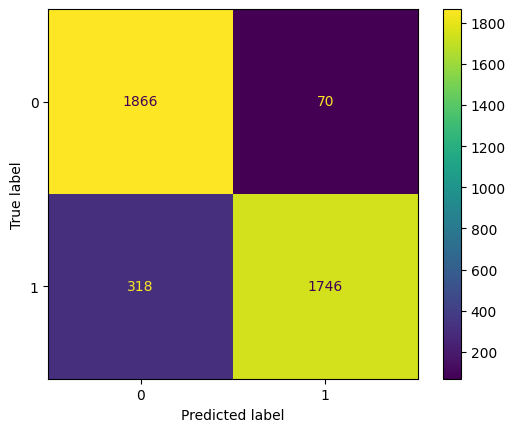

In [9]:
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
correct = 0
preds=[]
for i,batch in enumerate(test_loader):
    input_ids=batch["input_ids"].to(device)
    attention_mask=batch["attention_mask"].to(device)
    labels=batch["labels"].to(device)

    with torch.no_grad():
        prediction=model(input_ids,attention_mask=attention_mask)
    loss=loss_fn(prediction.logits.flatten(),labels)
    batch_loss=loss.item()
    print(f"Batch {i}, loss {batch_loss/batch_size:.6f}")
    pred=torch.round(Sigmoid()(prediction.logits.flatten()))
    preds.append(pred.to("cpu"))
    correct+=(pred==labels).sum().item()
    print(f"Accuracy: {correct/((i+1)*batch_size):.5f}")

preds=np.hstack(preds)
f1=f1_score(test_loader.dataset.labels,np.round(preds))
print(f"F1 score = {f1}")
ConfusionMatrixDisplay.from_predictions(test_loader.dataset.labels,np.round(preds))
plt.show()


In [10]:
torch.save(model.state_dict(),"BERT.pt")

In [28]:
review=input("Write your review and I'll tell you whether I think it's positive or negative: ")
review_toks=tokenizer([review],padding=True,truncation=True)
prediction=model(torch.tensor(review_toks["input_ids"]).to(device),attention_mask=torch.tensor(review_toks["attention_mask"]).float().to(device))
print(["negative","positive"][int(torch.round(Sigmoid()(prediction.logits)).item())])

Write your review and I'll tell you whether I think it's positive or negative: I could buy this every day
positive
